# Reto 6 - Clasificación de Imágenes (Cat vs Dog)

Clasificación binaria de imágenes de gatos y perros usando **SVM** y **Random Forest** con búsqueda de hiperparámetros mediante `GridSearchCV`.

## 1. Importar Librerías

In [2]:
import pandas as pd
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## 2. Definir Rutas y Categorías

In [3]:
datadir = 'Dataset500/'
Categories = ['Cat', 'Dog']
flat_data_arr = []
target_arr = []

## 3. Cargar y Preprocesar el Dataset

Se leen las imágenes de cada categoría, se redimensionan a `(150, 150, 3)` y se aplanan a vectores de 67,500 elementos.

In [4]:
for i in Categories:
    print(f'loading... category: {i}')
    path = os.path.join(datadir, i)

    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        try:
            img_array = imread(img_path)
            img_resized = resize(img_array, (150, 150, 3), anti_aliasing=True)

            # Validar tamaño esperado
            if img_resized.flatten().shape == (67500,):
                flat_data_arr.append(img_resized.flatten())
                target_arr.append(Categories.index(i))
        except Exception as e:
            print(f'Error cargando {img_path}: {e}')

    print(f'loaded category: {i} successfully')

flat_data = np.array(flat_data_arr)
target = np.array(target_arr)

loading... category: Cat
loaded category: Cat successfully
loading... category: Dog
loaded category: Dog successfully


## 4. Explorar los Datos Cargados

Shape de X: (999, 67500)
Shape de y: (999,)
  Clase Cat: 499 imágenes
  Clase Dog: 500 imágenes


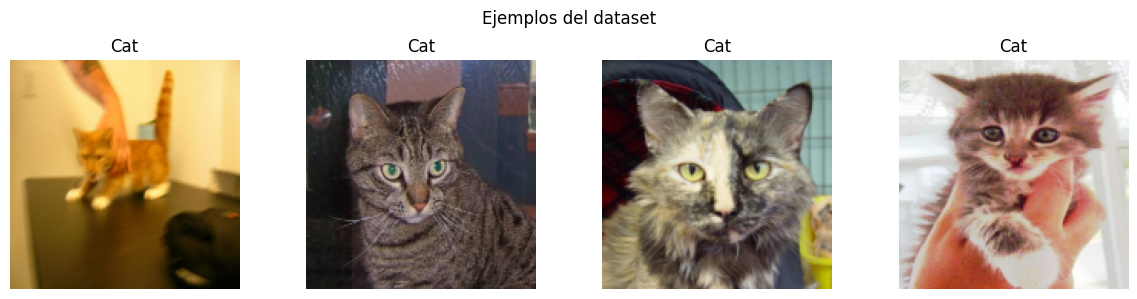

In [5]:
print("Shape de X:", flat_data.shape)
print("Shape de y:", target.shape)

# Distribución de clases
unique, counts = np.unique(target, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Clase {Categories[u]}: {c} imágenes")

# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for idx, ax in enumerate(axes):
    img = flat_data[idx].reshape(150, 150, 3)
    ax.imshow(img)
    ax.set_title(Categories[target[idx]])
    ax.axis('off')
plt.suptitle("Ejemplos del dataset")
plt.tight_layout()
plt.show()

## 5. Dividir Datos en Entrenamiento y Test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    flat_data,
    target,
    test_size=0.20,
    random_state=77,
    stratify=target
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (799, 67500)
X_test: (200, 67500)
y_train: (799,)
y_test: (200,)


## 6. Definir Pipeline SVM con StandardScaler

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

param_grid = {
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10], # proporcion de errores permitidos
    'svc__gamma': ['scale', 0.01, 0.001] # coeficiente de kernel para 'rbf', cuanto más pequeño, más suave es la frontera de decisión
}                                        # 'scale' es el valor predeterminado que se ajusta automáticamente según el número de características

## 7. Ejecutar GridSearchCV para SVM

In [8]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=3
)

grid.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(grid.best_params_)
print(f"Mejor accuracy en validación cruzada: {grid.best_score_:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros encontrados:
{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Mejor accuracy en validación cruzada: 0.6144


## 8. Evaluar Modelo SVM en Test

In [9]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy en test: {acc:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=['cat', 'dog']))

Accuracy en test: 0.6100

Classification report:

              precision    recall  f1-score   support

         cat       0.61      0.62      0.61       100
         dog       0.61      0.60      0.61       100

    accuracy                           0.61       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.61      0.61      0.61       200



## 9. Visualizar Matriz de Confusión SVM

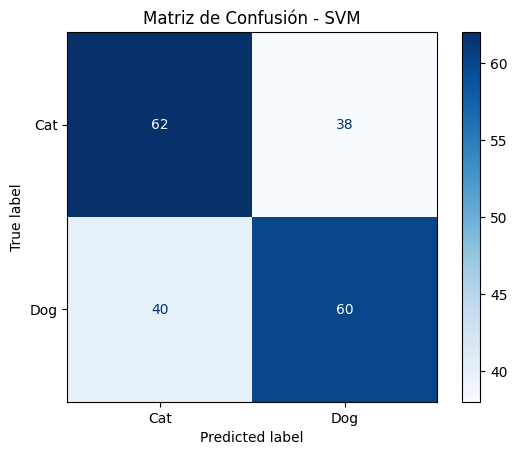

In [10]:
cm_svm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Cat', 'Dog'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - SVM")
plt.show()

## 10. Definir y Configurar Random Forest con GridSearchCV

In [11]:
rf = RandomForestClassifier(random_state=77)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5] # número mínimo de muestras necesarias para dividir un nodo
}

![Mathematical model: Random Forest formula](https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/2025/Shaoni/13-june/eq1.png)

> Construye múltiples árboles de decisión entrenados sobre muestras bootstrap y subconjuntos aleatorios de variables, combinando sus predicciones mediante votación (clasificación) o promedio (regresión) 

> Bootstrap es un método de muestreo en el que se seleccionan datos del dataset original de forma aleatoria y con reemplazo

## 11. Ejecutar GridSearchCV para Random Forest

In [12]:
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=3
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros RF:")
print(grid_rf.best_params_)
print(f"Mejor accuracy CV RF: {grid_rf.best_score_:.4f}") # CV: cross-validation, es decir, la mejor precisión obtenida durante la validación cruzada para el modelo de Random Forest.

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros RF:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Mejor accuracy CV RF: 0.6157


## 12. Evaluar Modelo Random Forest en Test

In [13]:
rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy RF en test: {acc_rf:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_rf, target_names=['cat', 'dog']))

Accuracy RF en test: 0.6100

Classification report:

              precision    recall  f1-score   support

         cat       0.61      0.63      0.62       100
         dog       0.61      0.59      0.60       100

    accuracy                           0.61       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.61      0.61      0.61       200



## 13. Visualizar Matriz de Confusión Random Forest

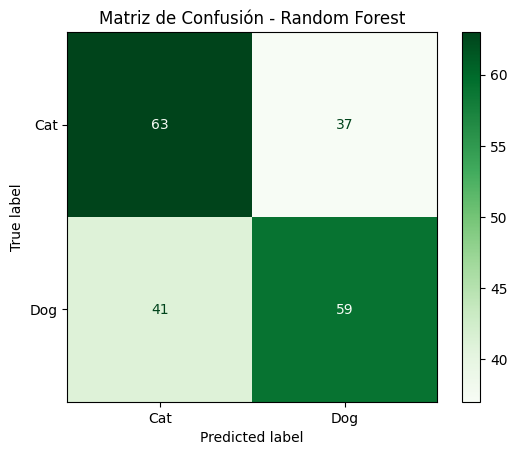

In [14]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Cat', 'Dog'])
disp_rf.plot(cmap='Greens')
plt.title("Matriz de Confusión - Random Forest")
plt.show()

## 14. Comparar Resultados de Ambos Modelos

       Modelo  Accuracy Test  Mejor Accuracy CV
          SVM           0.61           0.614439
Random Forest           0.61           0.615743


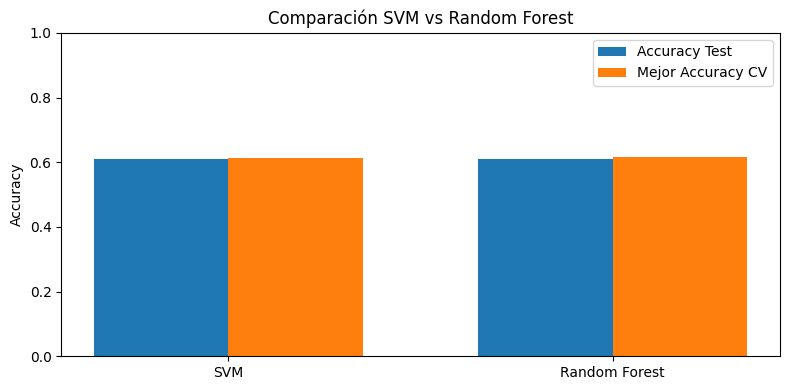


Mejores hiperparámetros SVM: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Mejores hiperparámetros RF: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [15]:
resultados = pd.DataFrame({
    'Modelo': ['SVM', 'Random Forest'],
    'Accuracy Test': [acc, acc_rf],
    'Mejor Accuracy CV': [grid.best_score_, grid_rf.best_score_]
})
print(resultados.to_string(index=False))

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(resultados))
width = 0.35
ax.bar(x - width/2, resultados['Accuracy Test'], width, label='Accuracy Test')
ax.bar(x + width/2, resultados['Mejor Accuracy CV'], width, label='Mejor Accuracy CV')
ax.set_xticks(x)
ax.set_xticklabels(resultados['Modelo'])
ax.set_ylabel('Accuracy')
ax.set_title('Comparación SVM vs Random Forest')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout() # Ajustar elementos para evitar solapamientos
plt.show()

print("\nMejores hiperparámetros SVM:", grid.best_params_)
print("Mejores hiperparámetros RF:", grid_rf.best_params_)

## 15. Conclusiones

- **Preprocesamiento:** Se cargaron y redimensionaron las imágenes a un tamaño uniforme de 150×150 píxeles, aplanándolas en vectores de 67,500 características para alimentar los modelos de Machine Learning tradicional.

- **SVM (Support Vector Machine):** Mediante `GridSearchCV` se exploraron combinaciones de kernel (`linear`, `rbf`), regularización (`C`) y coeficiente `gamma`. SVM demostró ser un clasificador robusto al encontrar hiperplanos de separación óptimos en un espacio de alta dimensionalidad.

- **Random Forest:** Se optimizaron hiperparámetros como el número de árboles (`n_estimators`), profundidad máxima (`max_depth`) y muestras mínimas para dividir un nodo (`min_samples_split`). Al combinar múltiples árboles de decisión mediante votación, Random Forest logra reducir el sobreajuste frente a un árbol individual.

- **Comparación de modelos:** La tabla y gráfica comparativa permiten contrastar el accuracy en test y en validación cruzada de ambos modelos, facilitando la selección del más adecuado para este problema de clasificación binaria.

- **Validación cruzada:** El uso de `GridSearchCV` con `cv=3` garantiza que la evaluación de hiperparámetros no dependa de una sola partición de datos, brindando estimaciones más confiables del rendimiento real de cada modelo.

- **Limitaciones:** Al trabajar con píxeles aplanados se pierde la información espacial de las imágenes. Enfoques basados en redes neuronales convolucionales (CNN) podrían capturar mejor las relaciones espaciales y mejorar la precisión de la clasificación.